In [372]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score
from sklearn import datasets, linear_model, metrics
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score
import os
import warnings

In [373]:
news_data = pd.read_csv("fake_news_dataset.csv")

In [374]:
news_data.head()

,id,title,author,text,state,date_published,source,category,sentiment_score,word_count,...,num_shares,num_comments,political_bias,fact_check_rating,is_satirical,trust_score,source_reputation,clickbait_score,plagiarism_score,label
0,1,Breaking News 1,Jane Smith,This is the content of article 1. It contains ...,Tennessee,30-11-2021,The Onion,Entertainment,-0.22,1302,...,47305,450,Center,FALSE,1,76,6,0.84,53.35,Fake
1,2,Breaking News 2,Emily Davis,This is the content of article 2. It contains ...,Wisconsin,02-09-2021,The Guardian,Technology,0.92,322,...,39804,530,Left,Mixed,1,1,5,0.85,28.28,Fake
2,3,Breaking News 3,John Doe,This is the content of article 3. It contains ...,Missouri,13-04-2021,New York Times,Sports,0.25,228,...,45860,763,Center,Mixed,0,57,1,0.72,0.38,Fake
3,4,Breaking News 4,Alex Johnson,This is the content of article 4. It contains ...,North Carolina,08-03-2020,CNN,Sports,0.94,155,...,34222,945,Center,TRUE,1,18,10,0.92,32.20,Fake
4,5,Breaking News 5,Emily Davis,This is the content of article 5. It contains ...,California,23-03-2022,Daily Mail,Technology,-0.01,962,...,35934,433,Right,Mixed,0,95,6,0.66,77.70,Real


In [375]:
news_data.describe()

,id,sentiment_score,word_count,char_count,has_images,has_videos,readability_score,num_shares,num_comments,is_satirical,trust_score,source_reputation,clickbait_score,plagiarism_score
count,4000.000000,4000.000000,4000.000000,4000.0000,4000.00000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.00000,4000.000000,4000.000000
mean,2000.500000,-0.000645,795.655750,4277.0680,0.49650,0.484500,54.764595,25144.596750,489.870250,0.497000,49.960750,5.54925,0.494447,50.598110
std,1154.844867,0.574768,406.373871,2186.2073,0.50005,0.499822,14.404027,14387.537467,287.435733,0.500054,29.467911,2.87422,0.289138,28.932298
min,1.000000,-1.000000,100.000000,500.0000,0.00000,0.000000,30.020000,39.000000,0.000000,0.000000,0.000000,1.00000,0.000000,0.040000
25%,1000.750000,-0.490000,445.750000,2358.7500,0.00000,0.000000,42.480000,12781.750000,238.000000,0.000000,24.000000,3.00000,0.240000,25.915000
50%,2000.500000,-0.010000,793.000000,4287.0000,0.00000,0.000000,54.235000,25308.500000,483.000000,0.000000,50.000000,6.00000,0.490000,51.480000
75%,3000.250000,0.510000,1150.000000,6206.5000,1.00000,1.000000,67.215000,37453.500000,741.000000,1.000000,76.000000,8.00000,0.740000,75.580000
max,4000.000000,1.000000,1500.000000,7996.0000,1.00000,1.000000,79.980000,50000.000000,1000.000000,1.000000,100.000000,10.00000,1.000000,99.950000


In [376]:
print(news_data.isnull().sum())

id                   0
title                0
author               0
text                 0
state                0
date_published       0
source               0
category             0
sentiment_score      0
word_count           0
char_count           0
has_images           0
has_videos           0
readability_score    0
num_shares           0
num_comments         0
political_bias       0
fact_check_rating    0
is_satirical         0
trust_score          0
source_reputation    0
clickbait_score      0
plagiarism_score     0
label                0
dtype: int64


In [377]:
news_data.dtypes

id                     int64
title                 object
author                object
text                  object
state                 object
date_published        object
source                object
category              object
sentiment_score      float64
word_count             int64
char_count             int64
has_images             int64
has_videos             int64
readability_score    float64
num_shares             int64
num_comments           int64
political_bias        object
fact_check_rating     object
is_satirical           int64
trust_score            int64
source_reputation      int64
clickbait_score      float64
plagiarism_score     float64
label                 object
dtype: object

In [378]:
news_data = pd.get_dummies(news_data, columns=['source', 'political_bias', 'category', 'fact_check_rating',], drop_first=True, dtype=int)
print(news_data.head())
print("Num Satirical: ",news_data["is_satirical"].sum())
news_data = news_data[news_data["is_satirical"] != 1]
news_data = news_data.drop('is_satirical', axis=1)

   id            title        author  \
0   1  Breaking News 1    Jane Smith   
1   2  Breaking News 2   Emily Davis   
2   3  Breaking News 3      John Doe   
3   4  Breaking News 4  Alex Johnson   
4   5  Breaking News 5   Emily Davis   

                                                text           state  \
0  This is the content of article 1. It contains ...       Tennessee   
1  This is the content of article 2. It contains ...       Wisconsin   
2  This is the content of article 3. It contains ...        Missouri   
3  This is the content of article 4. It contains ...  North Carolina   
4  This is the content of article 5. It contains ...      California   

  date_published  sentiment_score  word_count  char_count  has_images  ...  \
0     30-11-2021            -0.22        1302        5070           0  ...   
1     02-09-2021             0.92         322        2722           1  ...   
2     13-04-2021             0.25         228        5904           0  ...   
3     08-03-20

In [379]:
news_data = news_data.drop(['id'], axis=1)
news_data = news_data.drop(['author'], axis=1)
news_data = news_data.drop(['title'], axis=1)
news_data = news_data.drop(['text'], axis=1)
news_data = news_data.drop(['state'], axis=1)
news_data = news_data.drop(['date_published'], axis=1)

In [380]:
scaler = StandardScaler()

In [381]:
news_data['label'] = news_data['label'].str.strip().str.lower()
news_data = news_data[news_data['label'].isin(['fake', 'real'])]

In [382]:
y = news_data['label'].map({'fake': 1, 'real': 0})


In [383]:
print(y.isnull().sum())

0


In [384]:
X = news_data.drop(['label'], axis =1)

In [385]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [386]:
# Initialize the logistic regression model
model = LogisticRegression()

In [416]:
model = LogisticRegression()
model.fit(X_train, y_train)

C:\Users\Eric\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

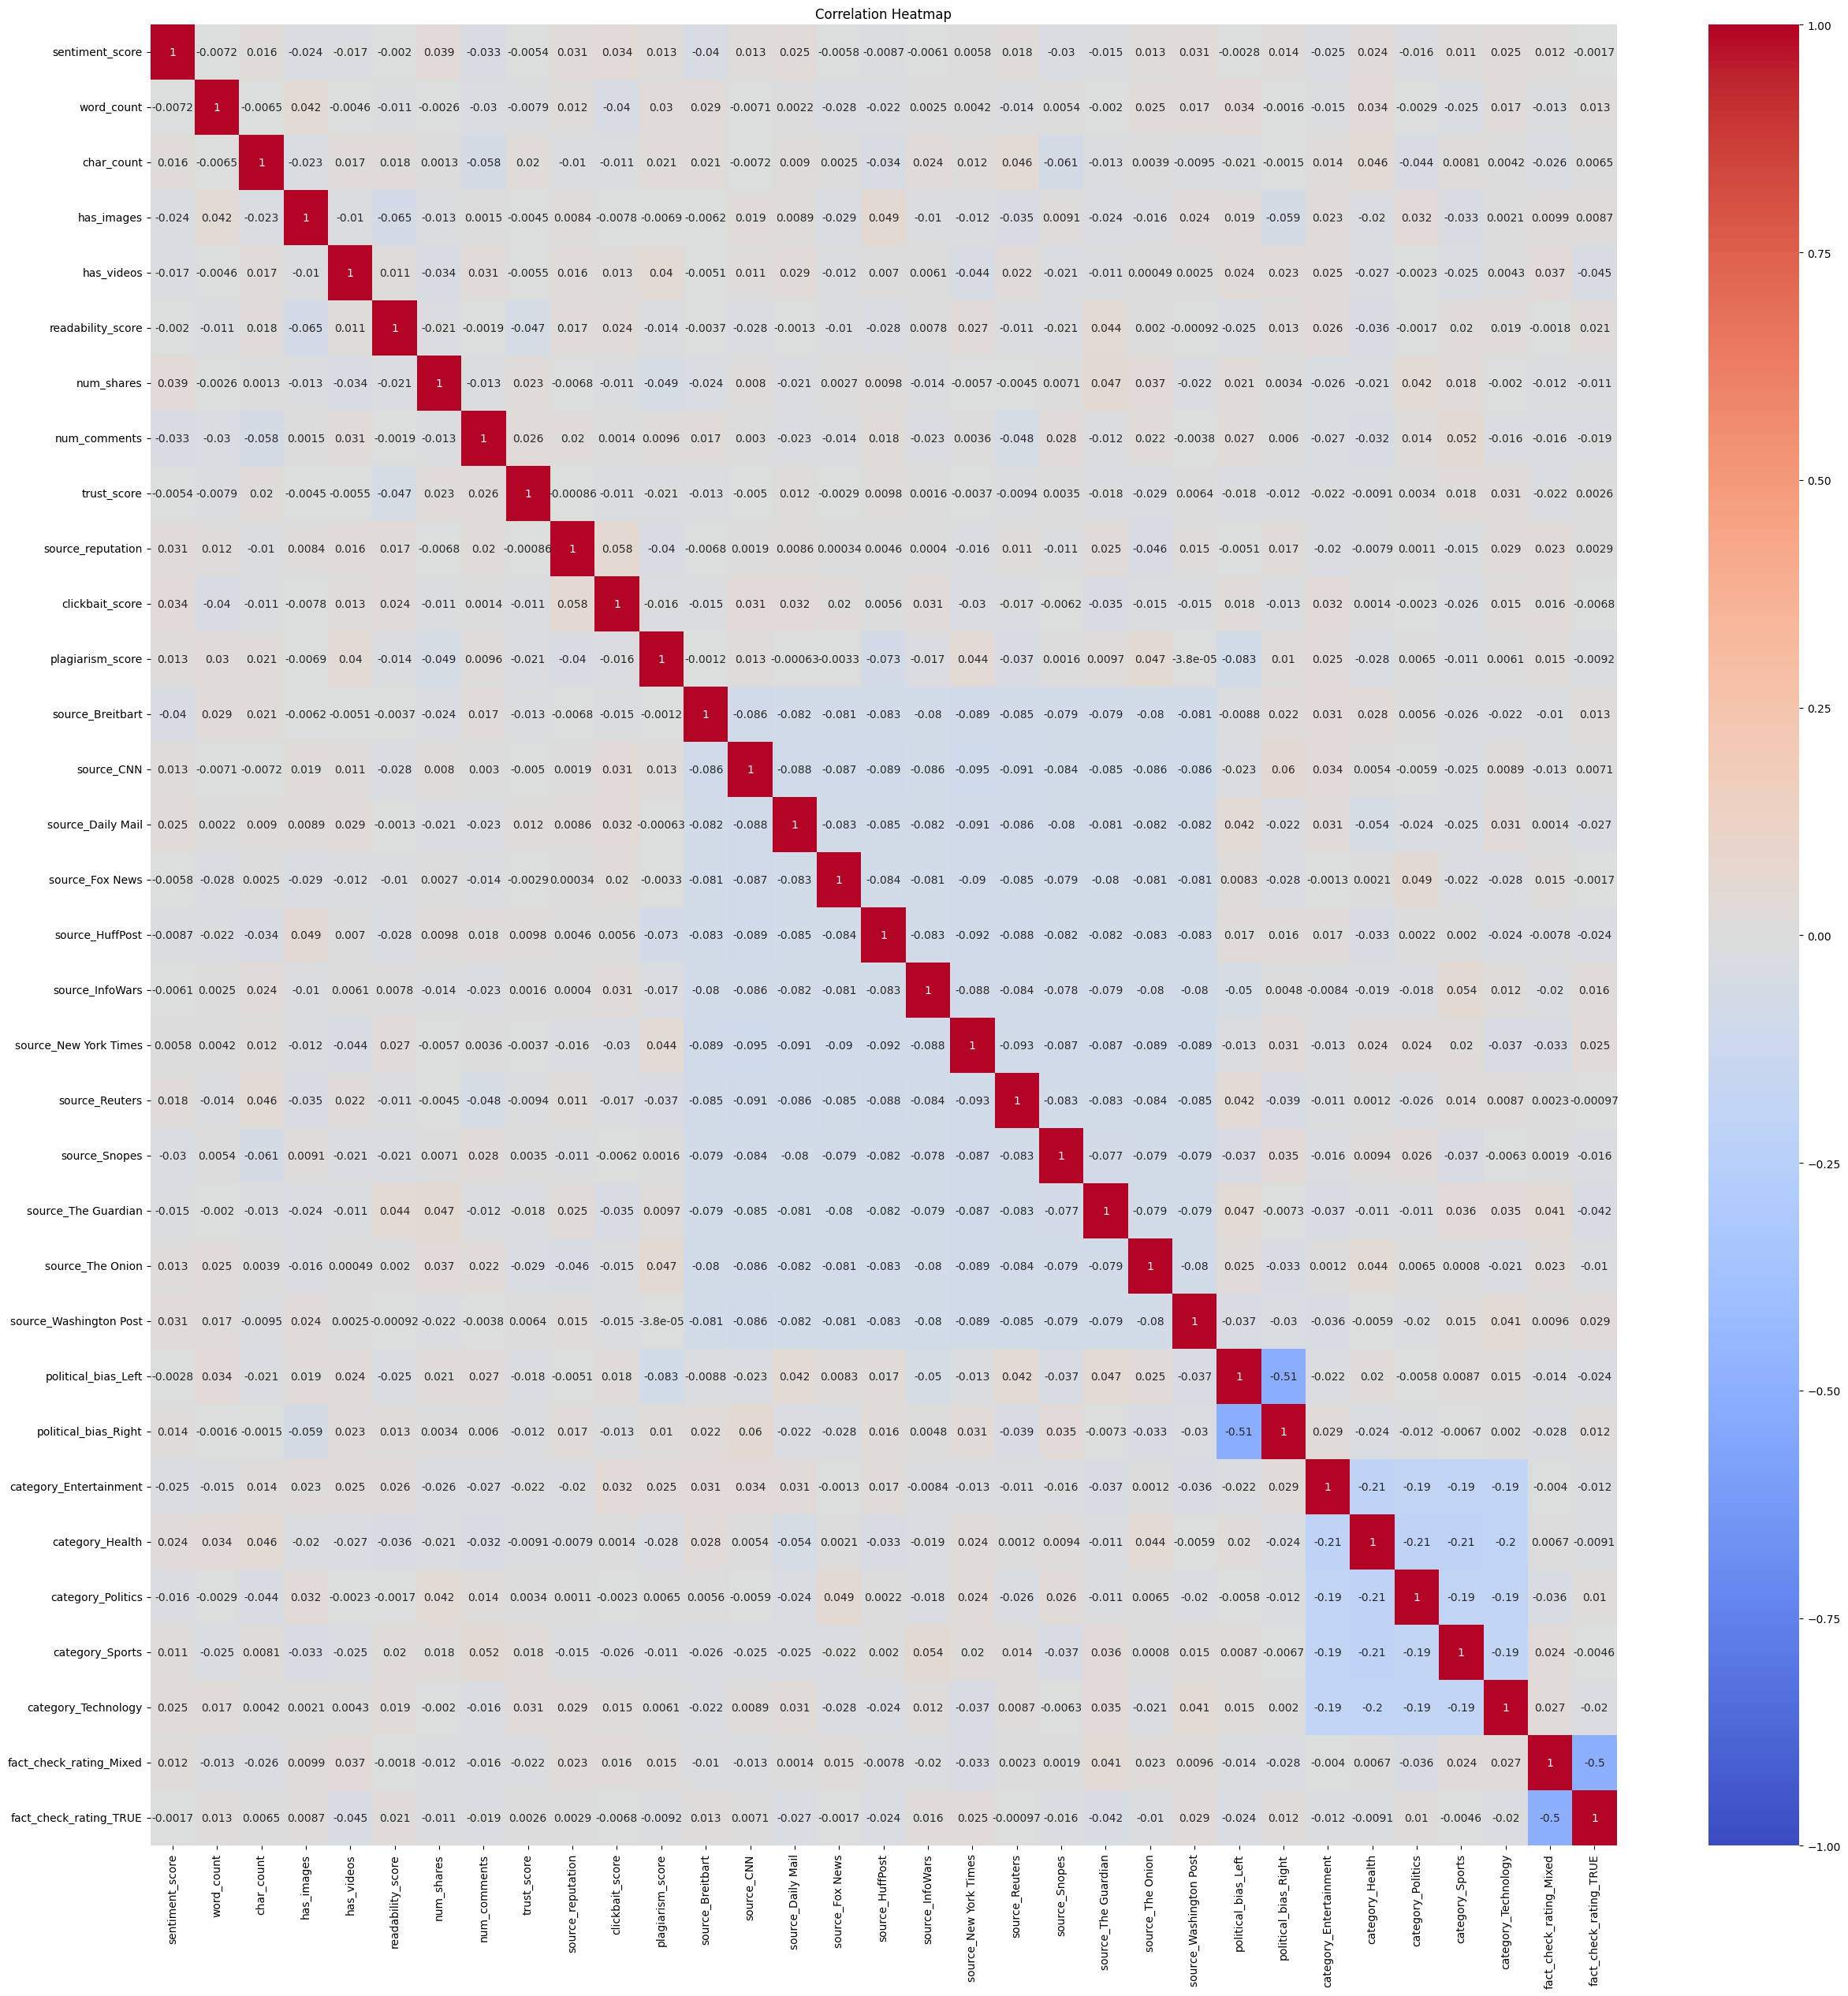

In [418]:
corr_matrix = X.corr()
plt.figure(figsize=(30,30))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1,vmax=1)
plt.title('Correlation Heatmap')
plt.show()

In [419]:
y_pred = model.predict(X_test)

In [420]:
from sklearn.metrics import mean_squared_error, r2_score
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)

Mean Squared Error: 0.4441687344913151


In [421]:
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy * 100:.2f}%')

Accuracy: 55.58%


In [422]:
precision = precision_score(y_test, y_pred)
print("Precision:", precision)
recall = metrics.recall_score(y_test, y_pred)
print("Recall:", recall)

Precision: 0.582010582010582
Recall: 0.5238095238095238


In [430]:
from sklearn.ensemble import RandomForestClassifier
model2 = RandomForestClassifier()
model2.fit(X_train, y_train)

RandomForestClassifier()

In [432]:
y2_pred = model2.predict(X_test)

In [434]:
accuracy = accuracy_score(y_test, y2_pred)
print(f'Accuracy: {accuracy * 100:.2f}%')

Accuracy: 46.40%


In [436]:
precision = precision_score(y_test, y2_pred)
print("Precision:", precision)
recall = metrics.recall_score(y_test, y2_pred)
print("Recall:", recall)

Precision: 0.485
Recall: 0.46190476190476193


In [440]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, roc_auc_score,
                             confusion_matrix, roc_curve, classification_report)

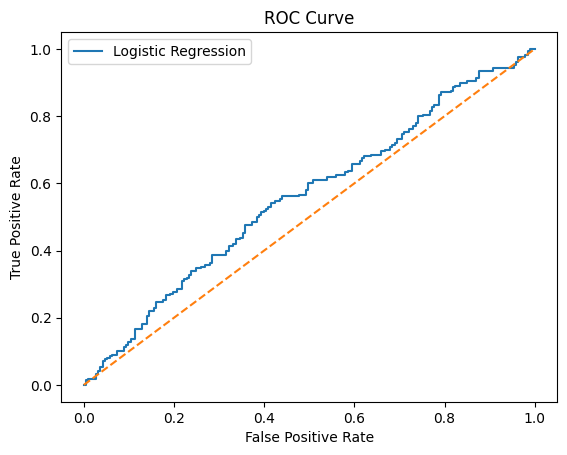

In [444]:
y_pred_prob = model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
plt.plot(fpr, tpr, label='Logistic Regression')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [446]:
#test1
print("ROC AUC:", roc_auc_score(y_test, y_pred_prob))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

ROC AUC: 0.5584998766345917

Classification Report:
               precision    recall  f1-score   support

           0       0.53      0.59      0.56       193
           1       0.58      0.52      0.55       210

    accuracy                           0.56       403
   macro avg       0.56      0.56      0.56       403
weighted avg       0.56      0.56      0.56       403

